# Пердварительный анализ

In [1]:
from pathlib import Path

import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

In [2]:
train = pd.read_csv("../data/train.csv")
print("train:", train.shape)
train.head(3)

train: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


In [3]:
test_labels = pd.read_csv("../data/test_labels.csv")

# убираем -1
total_labels = len(test_labels)
unscored_labels = (test_labels[LABELS] == -1).any(axis=1).sum()

print(f"total labels: {total_labels}, unscored labels: {unscored_labels} ({unscored_labels/total_labels * 100 }%)")

total labels: 153164, unscored labels: 89186 (58.22908777519522%)


In [ ]:
print("nulls:", train["comment_text"].isnull().sum())
print("dups:", train["comment_text"].duplicated().sum())
print("empty:", (train["comment_text"].str.strip() == "").sum())

# метки должны быть 0/1
print("label values:", sorted(pd.unique(train[LABELS].values.ravel())))
train[LABELS].describe().loc[["mean", "min", "max"]]

nulls: 0
dups: 0
empty: 0
label values: [np.int64(0), np.int64(1)]


,toxic,severe_toxic,obscene,threat,insult,identity_hate
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


               count  percent
toxic          15294     9.58
obscene         8449     5.29
insult          7877     4.94
severe_toxic    1595     1.00
identity_hate   1405     0.88
threat           478     0.30


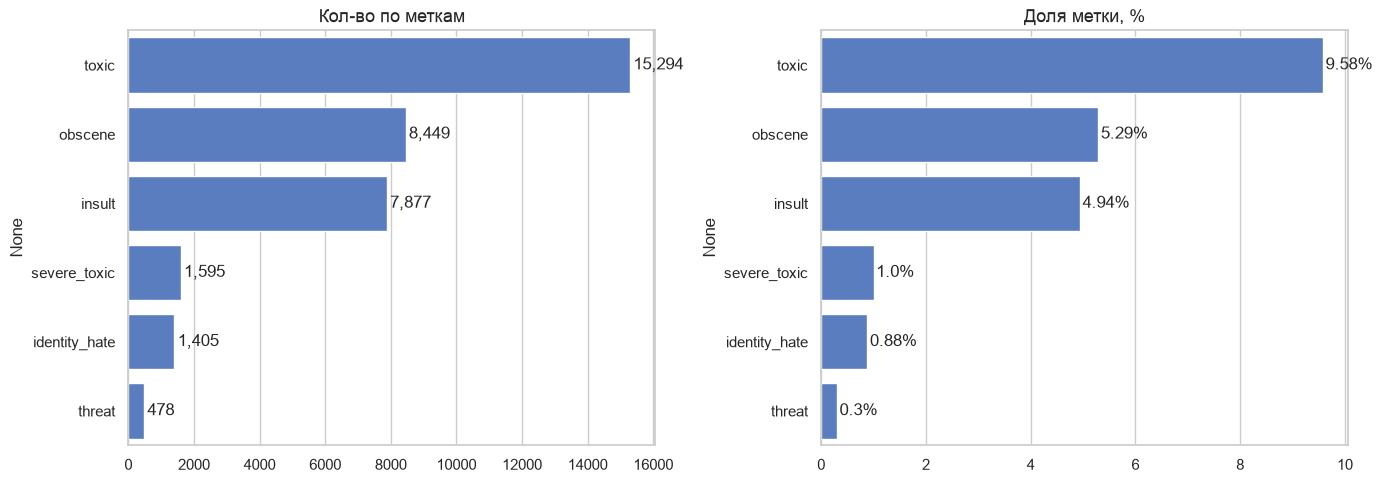

In [5]:
label_counts = train[LABELS].sum().sort_values(ascending=False)
label_pct = (train[LABELS].mean() * 100).round(2).sort_values(ascending=False)
print(pd.DataFrame({"count": label_counts, "percent": label_pct}))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=label_counts.values, y=label_counts.index, ax=ax[0])
ax[0].set_title("Кол-во по меткам")
for i, v in enumerate(label_counts.values):
    ax[0].text(v + 100, i, f"{v:,}", va="center")

sns.barplot(x=label_pct.values, y=label_pct.index, ax=ax[1])
ax[1].set_title("Доля метки, %")
for i, v in enumerate(label_pct.values):
    ax[1].text(v + 0.05, i, f"{v}%", va="center")

plt.tight_layout()
plt.show()

clean: 143346 (89.8%), toxic: 16225 (10.2%)


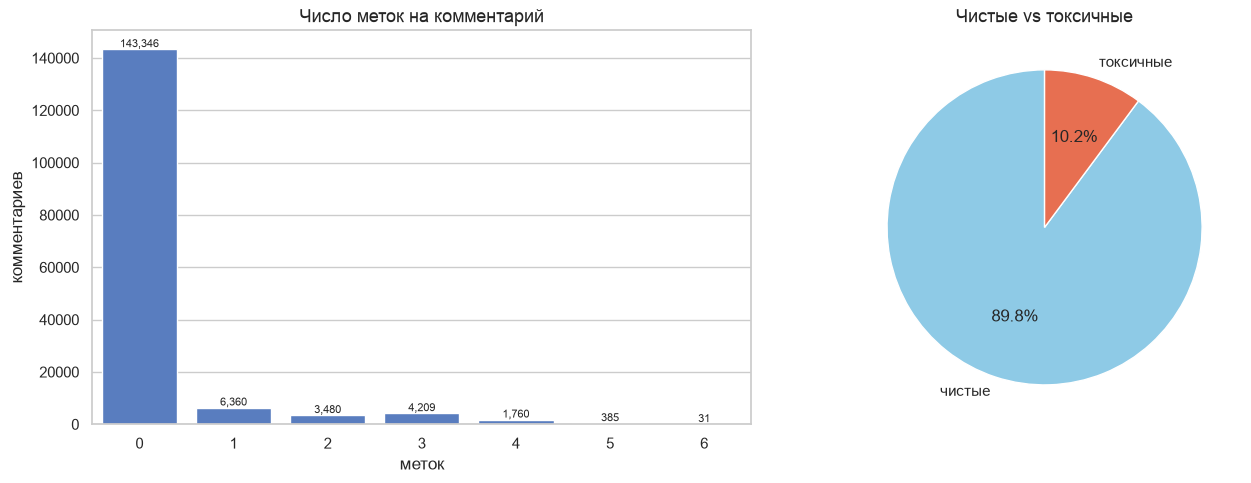

In [6]:
n_labels = train[LABELS].sum(axis=1)
dist = n_labels.value_counts().sort_index()

clean = int((n_labels == 0).sum())
toxic_any = int((n_labels > 0).sum())
print(f"clean: {clean} ({clean/len(train):.1%}), toxic: {toxic_any} ({toxic_any/len(train):.1%})")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=dist.index, y=dist.values, ax=ax[0])
ax[0].set(title="Число меток на комментарий", xlabel="меток", ylabel="комментариев")
for i, v in zip(dist.index, dist.values):
    ax[0].text(i, v + 800, f"{v:,}", ha="center", fontsize=8)

ax[1].pie([clean, toxic_any], labels=["чистые", "токсичные"],
          autopct="%1.1f%%", startangle=90, colors=["#8ecae6", "#e76f51"])
ax[1].set_title("Чистые vs токсичные")

plt.tight_layout()
plt.show()

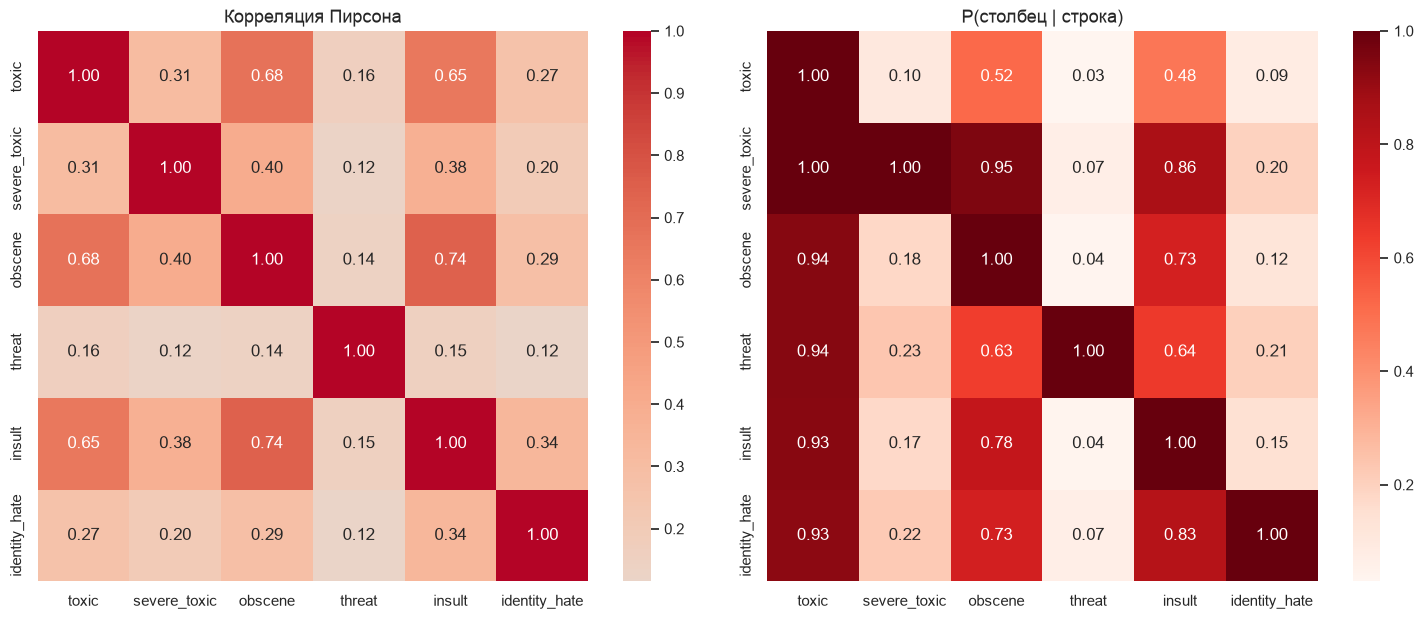

In [7]:
corr = train[LABELS].corr()

# P(столбец | строка): среди коммент. с меткой строки доля ещё и с меткой столбца
co = np.zeros((len(LABELS), len(LABELS)))
for i, a in enumerate(LABELS):
    base = train[train[a] == 1]
    for j, b in enumerate(LABELS):
        co[i, j] = base[b].mean()
co = pd.DataFrame(co, index=LABELS, columns=LABELS)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax[0])
ax[0].set_title("Корреляция Пирсона")
sns.heatmap(co, annot=True, fmt=".2f", cmap="Reds", square=True, ax=ax[1])
ax[1].set_title("P(столбец | строка)")
plt.tight_layout()
plt.show()

In [8]:
train["char_len"] = train["comment_text"].str.len()
train["word_len"] = train["comment_text"].str.split().apply(len)
train["is_toxic"] = np.where(n_labels > 0, "токсичный", "чистый")

print(train[["char_len", "word_len"]].describe().round(1))

# перцентили длины в словах — для выбора max_len
for q in (0.90, 0.95, 0.99):
    print(f"word_len {q:.0%}: {train['word_len'].quantile(q):.0f}")

       char_len  word_len
count  159571.0  159571.0
mean      394.1      67.3
std       590.7      99.2
min         6.0       1.0
25%        96.0      17.0
50%       205.0      36.0
75%       435.0      75.0
max      5000.0    1411.0
word_len 90%: 152
word_len 95%: 230
word_len 99%: 567


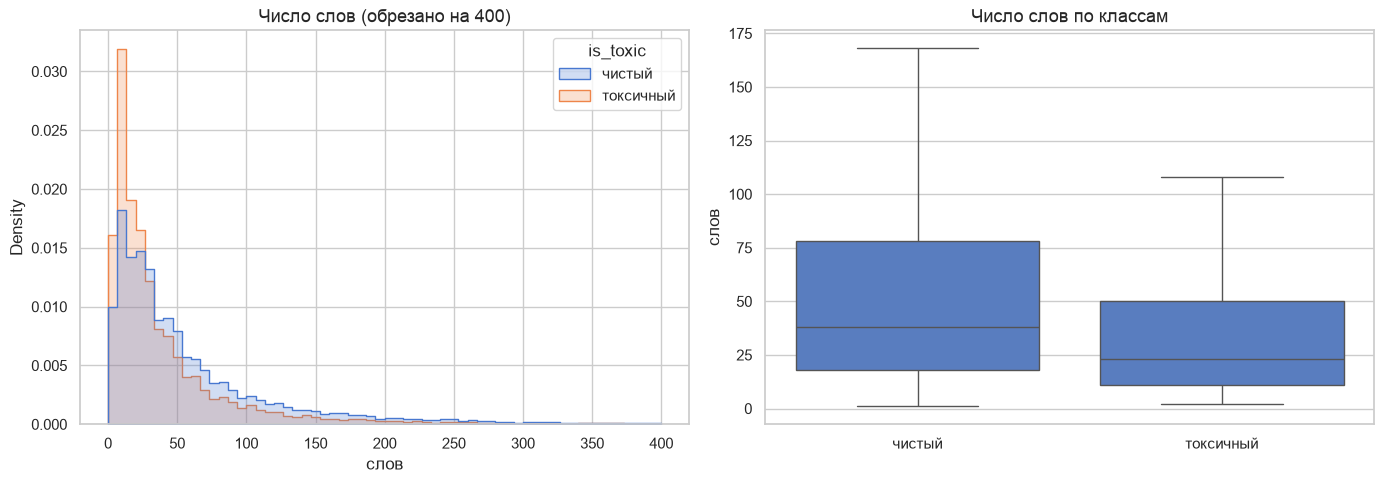

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# обрезаю ось x, иначе длинный хвост сплющит гистограмму
sns.histplot(data=train, x="word_len", hue="is_toxic", bins=60,
             binrange=(0, 400), stat="density", common_norm=False,
             element="step", ax=ax[0])
ax[0].set(title="Число слов (обрезано на 400)", xlabel="слов")

sns.boxplot(data=train, x="is_toxic", y="word_len", ax=ax[1], showfliers=False)
ax[1].set(title="Число слов по классам", xlabel="", ylabel="слов")

plt.tight_layout()
plt.show()

# Очистка текста

In [58]:
def clean_text(text):
    if not isinstance(text, str):   # NaN / не строка
        return ""
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)        # ссылки
    text = re.sub(r"\b(?:\d{1,3}\.){3}\d{1,3}\b", " ", text)  # ip
    text = re.sub(r"(\\n|\\t|\\r|\n|\t|\r)+", " ", text)      # переводы строк
    text = re.sub(r"[^a-z0-9\s.,!?']", " ", text)             # мусор
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample = train.loc[train["char_len"].between(120, 220), "comment_text"].iloc[7]
print("raw:\n", sample, "\n")
print("clean:\n", clean_text(sample))

raw:
 "

 DH 
Dude, ABC officially says THIS is the name for that episode. I do know there is already an episode with that name, but ABC says it's ""Everybody's Says Don't"".   " 

clean:
 dh dude, abc officially says this is the name for that episode. i do know there is already an episode with that name, but abc says it's everybody's says don't .


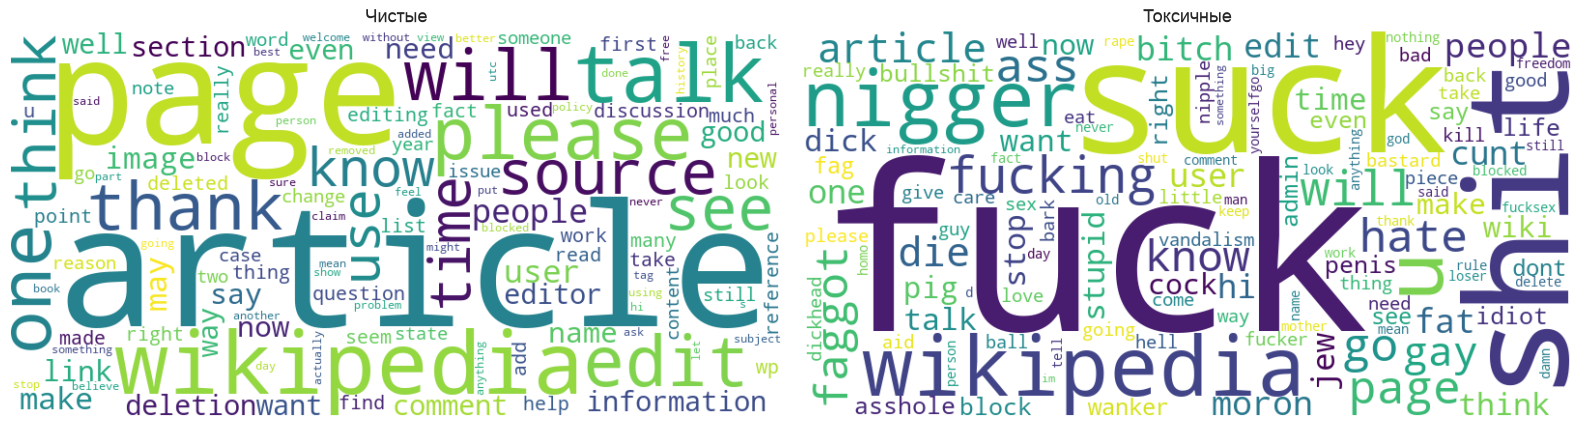

In [12]:
from wordcloud import WordCloud, STOPWORDS

def make_cloud(mask, title, ax):
    text = " ".join(train.loc[mask, "comment_text"].apply(clean_text))
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=STOPWORDS, max_words=120,
                   collocations=False).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
make_cloud(n_labels == 0, "Чистые", ax[0])
make_cloud(n_labels > 0, "Токсичные", ax[1])
plt.tight_layout()
plt.show()

## Чистка 

In [59]:
train_clean = train[["id", "comment_text"] + LABELS].copy()
train_clean["comment_text"] = train_clean["comment_text"].apply(clean_text)

test = pd.read_csv("../data/test.csv")
test_clean = test[["id", "comment_text"]].copy()
test_clean["comment_text"] = test_clean["comment_text"].apply(clean_text)

train_clean["comment_text"] = train_clean["comment_text"].replace("", "empty")
test_clean["comment_text"] = test_clean["comment_text"].replace("", "empty")

train_clean.to_csv("../data/train_clean.csv", index=False)
test_clean.to_csv("../data/test_clean.csv", index=False)

print("train_clean:", train_clean.shape)
print("test_clean:", test_clean.shape)

train_clean: (159571, 8)
test_clean: (153164, 2)


Очень сильный дисбаланс классов, метки сильно скоррелированны, так же есть неразмеченные данные, их надо выкинуть.